In [ ]:
from pathlib import Path
import pandas as pd


def compare_models(model_names, baseline_name, data_dir=".", metric="macro_pr_auc"):

    data_dir = Path(data_dir)

    if baseline_name not in model_names:
        raise ValueError(
            f"baseline_name='{baseline_name}' must be included in model_names"
        )

    results = {}

    for model_name in model_names:

        macro_file = (
            data_dir /
            f"training_metrics_model_{model_name}.csv"
        )

        per_class_file = (
            data_dir /
            f"per_class_training_metrics_model_{model_name}.csv"
        )

        if not macro_file.exists():
            raise FileNotFoundError(f"File not found: {macro_file}")

        if not per_class_file.exists():
            raise FileNotFoundError(f"File not found: {per_class_file}")

        macro_df = pd.read_csv(macro_file)
        per_class_df = pd.read_csv(per_class_file)

        # Best epoch according to macro PR-AUC
        best_idx = macro_df[metric].idxmax()
        best_epoch = macro_df.loc[best_idx, "epoch"]

        best_macro_pr_auc = macro_df.loc[
            best_idx, "macro_pr_auc"
        ]

        best_per_class = (
            per_class_df[
                per_class_df["epoch"] == best_epoch
            ]
            .set_index("class")["pr_auc"]
        )

        results[model_name] = {
            "best_epoch": best_epoch,
            "macro_pr_auc": best_macro_pr_auc,
            "per_class_pr_auc": best_per_class
        }

    baseline = results[baseline_name]
    rows = []
    classes = baseline["per_class_pr_auc"].index

    for model_name in model_names:

        result = results[model_name]

        row = {
            "Model": model_name,
            "Best epoch": result["best_epoch"],
            "Macro PR-AUC": result["macro_pr_auc"],
            "Macro Δ": (
                result["macro_pr_auc"]
                - baseline["macro_pr_auc"]
            )
        }

        for class_name in classes:

            value = result["per_class_pr_auc"].get(class_name)
            baseline_value = baseline["per_class_pr_auc"].get(class_name)

            row[f"{class_name} Δ"] = value - baseline_value

        rows.append(row)

    comparison = pd.DataFrame(rows)

    return comparison

In [3]:

base_model = "efficientnet_b4"
contrast_models = [
    "efficientnet_b4", 
    "efficientnet_b4_contrastclahe3", 
    "efficientnet_b4_contrastclahe2", 
    "efficientnet_b4_contrast_percentile", 
    "efficientnet_b4_contrastgamma08", 
    "efficientnet_b4_contrastgamma12"
    ]
datadir = "models"
metric = "macro_pr_auc"
comparison_contrast = compare_models(contrast_models, base_model, datadir, metric)
comparison_contrast

,Model,Best epoch,Macro PR-AUC,Macro Δ,Aortic enlargement Δ,Atelectasis Δ,Calcification Δ,Cardiomegaly Δ,Consolidation Δ,ILD Δ,Infiltration Δ,Lung Opacity Δ,Nodule/Mass Δ,Other lesion Δ,Pleural effusion Δ,Pleural thickening Δ,Pneumothorax Δ,Pulmonary fibrosis Δ
0,efficientnet_b4,11,0.566844,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,efficientnet_b4_contrastclahe3,7,0.538372,-0.028472,-0.007925,-0.081938,-0.077519,0.001012,-0.080549,0.060542,-0.009793,-0.015377,-0.007904,-0.001833,-0.026168,0.018670,-0.175770,0.005948
2,efficientnet_b4_contrastclahe2,7,0.547746,-0.019098,-0.027647,0.022098,-0.069486,0.007343,-0.059802,-0.005839,-0.003435,0.012949,0.028602,-0.020300,-0.007910,-0.025690,-0.109415,-0.008841
3,efficientnet_b4_contrast_percentile,8,0.534688,-0.032156,-0.023345,-0.145843,-0.132230,0.006532,-0.134298,0.050104,-0.006488,0.033587,-0.041112,0.021537,-0.054392,-0.000491,-0.002947,-0.020801
4,efficientnet_b4_contrastgamma08,8,0.552433,-0.014411,-0.000649,0.014349,-0.084110,0.000902,-0.040765,0.033207,0.009162,0.028759,-0.037885,0.001041,-0.010739,0.009262,-0.152489,0.028206
5,efficientnet_b4_contrastgamma12,13,0.546147,-0.020697,-0.006584,-0.011033,-0.102360,-0.001473,-0.026444,0.074639,-0.008538,-0.021045,-0.021917,0.003963,-0.006490,-0.001581,-0.141296,-0.019592


In [4]:
models = [
    "efficientnet_b4", 
    "efficientnet_b4_contrastclahe3", # +0.06 ild
    "efficientnet_b4_contrast_percentile", # +0.05 ild and +- 0 Pneumotorax (biggest drawbacks other contrast)
    "efficientnet_b4_contrastgamma12", # +0.07 ild
    "efficientnet_b4_augmentation",
    "efficientnet_b4_contrastclahe3_augmentation"
    ]
comparison = compare_models(models, base_model, datadir, metric)
comparison

,Model,Best epoch,Macro PR-AUC,Macro Δ,Aortic enlargement Δ,Atelectasis Δ,Calcification Δ,Cardiomegaly Δ,Consolidation Δ,ILD Δ,Infiltration Δ,Lung Opacity Δ,Nodule/Mass Δ,Other lesion Δ,Pleural effusion Δ,Pleural thickening Δ,Pneumothorax Δ,Pulmonary fibrosis Δ
0,efficientnet_b4,11,0.566844,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,efficientnet_b4_contrastclahe3,7,0.538372,-0.028472,-0.007925,-0.081938,-0.077519,0.001012,-0.080549,0.060542,-0.009793,-0.015377,-0.007904,-0.001833,-0.026168,0.018670,-0.175770,0.005948
2,efficientnet_b4_contrast_percentile,8,0.534688,-0.032156,-0.023345,-0.145843,-0.132230,0.006532,-0.134298,0.050104,-0.006488,0.033587,-0.041112,0.021537,-0.054392,-0.000491,-0.002947,-0.020801
3,efficientnet_b4_contrastgamma12,13,0.546147,-0.020697,-0.006584,-0.011033,-0.102360,-0.001473,-0.026444,0.074639,-0.008538,-0.021045,-0.021917,0.003963,-0.006490,-0.001581,-0.141296,-0.019592
4,efficientnet_b4_augmentation,8,0.595474,0.028630,0.013096,-0.061150,0.094243,0.019779,0.021560,0.034915,0.059099,0.047894,0.076153,0.020218,0.019342,0.037346,-0.043265,0.061591
5,efficientnet_b4_contrastclahe3_augmentation,11,0.552090,-0.014754,-0.008967,-0.130404,-0.008423,-0.014694,0.067598,-0.159164,0.034825,0.021686,0.035769,-0.017399,-0.006684,0.021363,-0.076111,0.034053


In [5]:
models = [
    "efficientnet_b4", 
    "efficientnet_b4_augmentation",
    "efficientnet_b4_augmentation-affine-contrastclahe-gaussnoise",
    "efficientnet_b4_augmentation-affine-contrastpercentile-gaussnoise"
    ]
comparison = compare_models(models, base_model, datadir, metric)
comparison

,Model,Best epoch,Macro PR-AUC,Macro Δ,Aortic enlargement Δ,Atelectasis Δ,Calcification Δ,Cardiomegaly Δ,Consolidation Δ,ILD Δ,Infiltration Δ,Lung Opacity Δ,Nodule/Mass Δ,Other lesion Δ,Pleural effusion Δ,Pleural thickening Δ,Pneumothorax Δ,Pulmonary fibrosis Δ
0,efficientnet_b4,11,0.566844,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,efficientnet_b4_augmentation,8,0.595474,0.028630,0.013096,-0.061150,0.094243,0.019779,0.021560,0.034915,0.059099,0.047894,0.076153,0.020218,0.019342,0.037346,-0.043265,0.061591
2,efficientnet_b4_augmentation-affine-contrastcl...,12,0.612432,0.045588,0.018637,0.074862,0.090890,0.053519,-0.015493,0.129519,0.030376,0.093212,0.116999,-0.002870,0.051723,-0.022876,-0.025671,0.045400
3,efficientnet_b4_augmentation-affine-contrastpe...,13,0.637817,0.070973,0.013653,0.171271,0.159410,0.039186,-0.013144,0.068631,0.083884,0.093049,0.141469,0.037918,0.081647,-0.008472,0.060764,0.064351


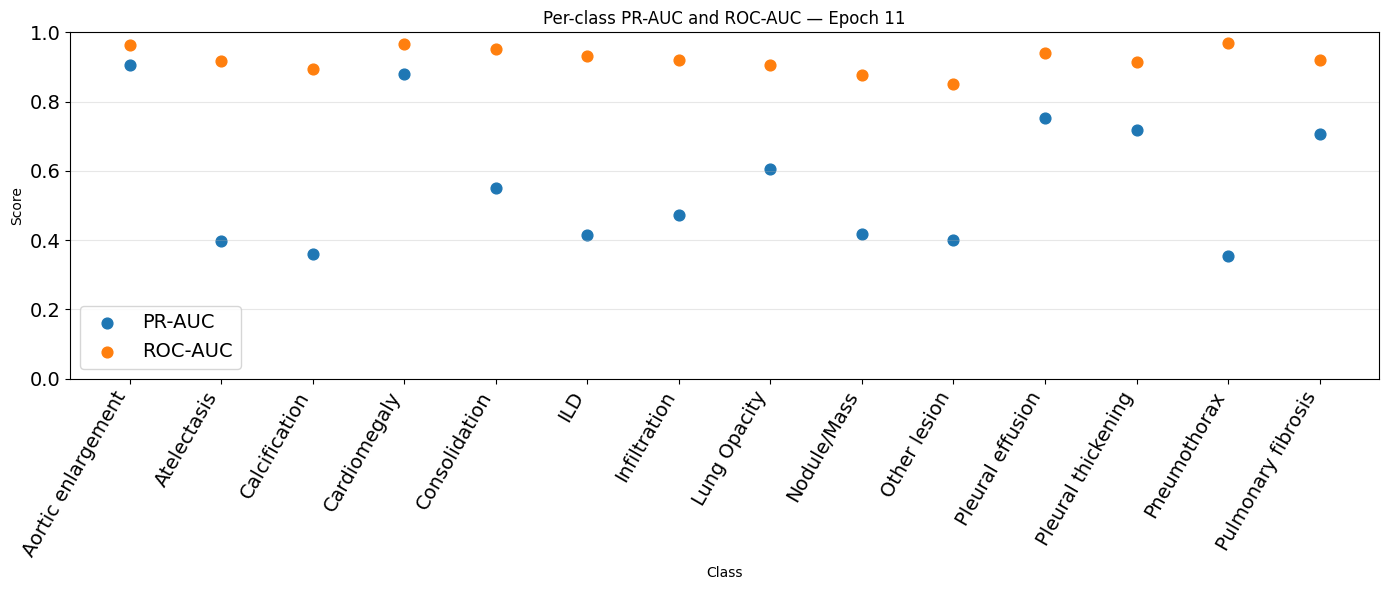

In [6]:
import matplotlib.pyplot as plt


def plot_per_class_metrics(per_class_df, epoch):

    df = per_class_df[
        per_class_df["epoch"] == epoch
    ].copy()

    df = df.sort_values("class")

    plt.figure(figsize=(14, 6))
    x = range(len(df))
    plt.scatter(x, df["pr_auc"], label="PR-AUC", s=60)
    plt.scatter(x, df["roc_auc"], label="ROC-AUC",s=60)
    plt.xticks(x, df["class"], rotation=60, ha="right", fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel("Class")
    plt.ylabel("Score")
    plt.title(f"Per-class PR-AUC and ROC-AUC — Epoch {epoch}")
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.show()

per_class_df = pd.read_csv(
    "models/per_class_training_metrics_model_efficientnet_b4.csv"
)

plot_per_class_metrics(
    per_class_df,
    epoch=11
)

In [7]:
models = [
    "efficientnet_b4", 
    "efficientnet_b4_augmentation",
    ]
comparison = compare_models(models, base_model, datadir, metric)
comparison

,Model,Best epoch,Macro PR-AUC,Macro Δ,Aortic enlargement Δ,Atelectasis Δ,Calcification Δ,Cardiomegaly Δ,Consolidation Δ,ILD Δ,Infiltration Δ,Lung Opacity Δ,Nodule/Mass Δ,Other lesion Δ,Pleural effusion Δ,Pleural thickening Δ,Pneumothorax Δ,Pulmonary fibrosis Δ
0,efficientnet_b4,11,0.566844,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,efficientnet_b4_augmentation,8,0.595474,0.02863,0.013096,-0.06115,0.094243,0.019779,0.02156,0.034915,0.059099,0.047894,0.076153,0.020218,0.019342,0.037346,-0.043265,0.061591


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_model_improvements(
    comparison,
    baseline_name,
    figsize=(16, 7),
    jitter_width=0.08
):
    df = comparison.copy()

    delta_columns = [
        col for col in df.columns
        if str(col).endswith(" Δ")
    ]
    if not delta_columns:
        raise ValueError(
            "No columns ending in ' Δ' were found in comparison."
        )

    class_names = [
        col[:-2]
        for col in delta_columns
    ]
    baseline_mask = df["Model"] == baseline_name
    if not baseline_mask.any():
        raise ValueError(
            f"Baseline '{baseline_name}' not found."
        )


    models = df[~baseline_mask].copy()
    n_models = len(models)
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(class_names))
    ax.axhline(
        0,
        linestyle="--",
        linewidth=1.5,
        label="Baseline"
    )
    if n_models > 1:
        offsets = np.linspace(
            -jitter_width,
            jitter_width,
            n_models
        )
    else:
        offsets = [0]


    for offset, (_, row) in zip(offsets, models.iterrows()):
        values = row[delta_columns].astype(float).values
        x_model = x + offset
        ax.plot(
            x_model,
            values,
            linewidth=0.8,
            alpha=0.6
        )
        ax.scatter(
            x_model,
            values,
            s=70,
            label=row["Model"],
            zorder=3
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        class_names,
        rotation=60,
        ha="right",
        fontsize=18
    )
    ax.tick_params(
        axis="y",
        labelsize=13
    )
    ax.set_xlabel(
        "Class",
        fontsize=15
    )
    ax.set_ylabel(
        "Δ PR-AUC relative to baseline",
        fontsize=15
    )
    ax.set_title(
        "Per-class improvement relative to baseline",
        fontsize=18,
        pad=15
    )
    ymin = models[delta_columns].min().min()
    ymax = models[delta_columns].max().max()
    margin = max((ymax - ymin) * 0.15, 0.005)
    ax.set_ylim(
        ymin - margin,
        ymax + margin
    )
    ax.grid(
        axis="y",
        alpha=0.3
    )

    # ax.legend(
    #     fontsize=16,
    #     loc="upper center",
    #     bbox_to_anchor=(0.5, -0.34),
    #     frameon=True,
    #     ncol=2

    # )
    plt.tight_layout()
    plt.show()

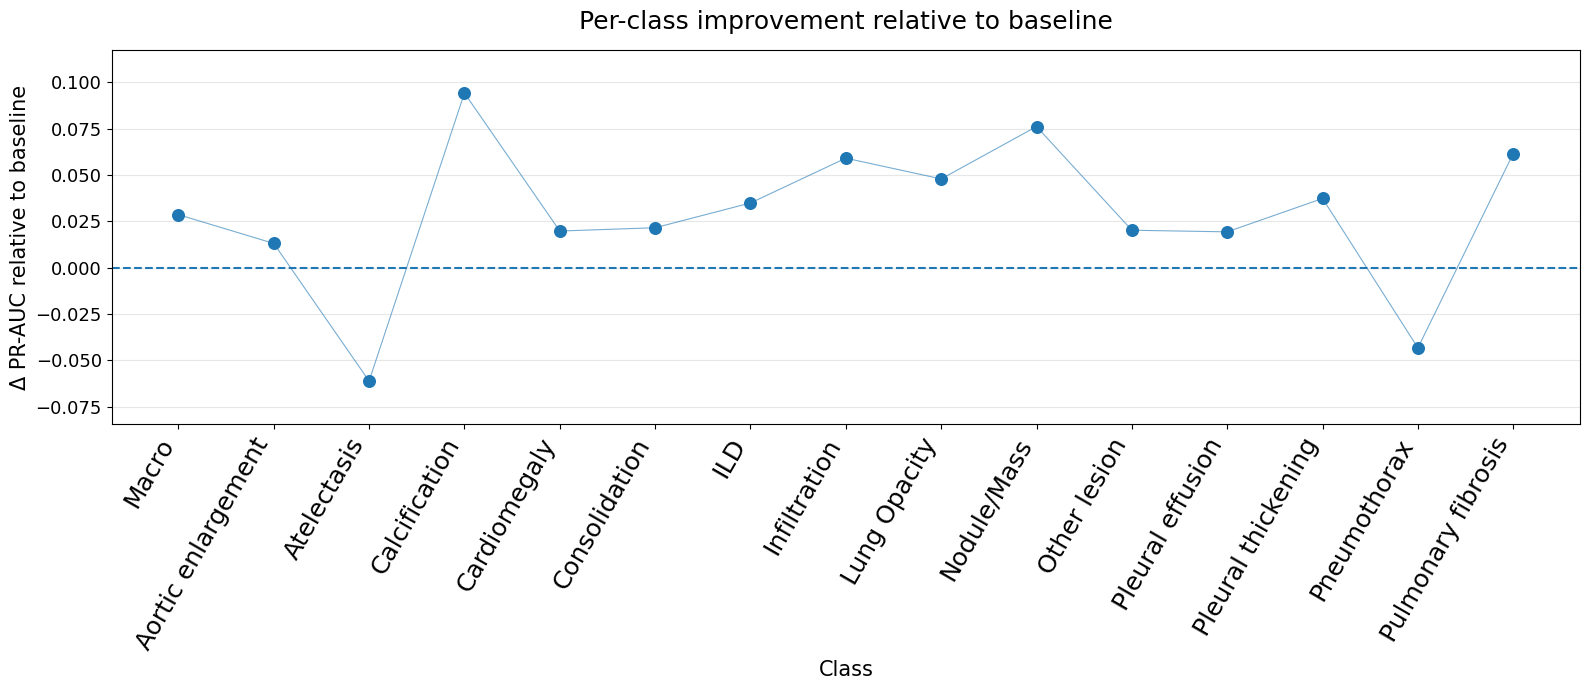

In [9]:
models = [
    "efficientnet_b4",
    "efficientnet_b4_augmentation",
]

comparison = compare_models(
    models,
    base_model,
    datadir,
    metric
)

plot_model_improvements(
    comparison,
    baseline_name=base_model
)

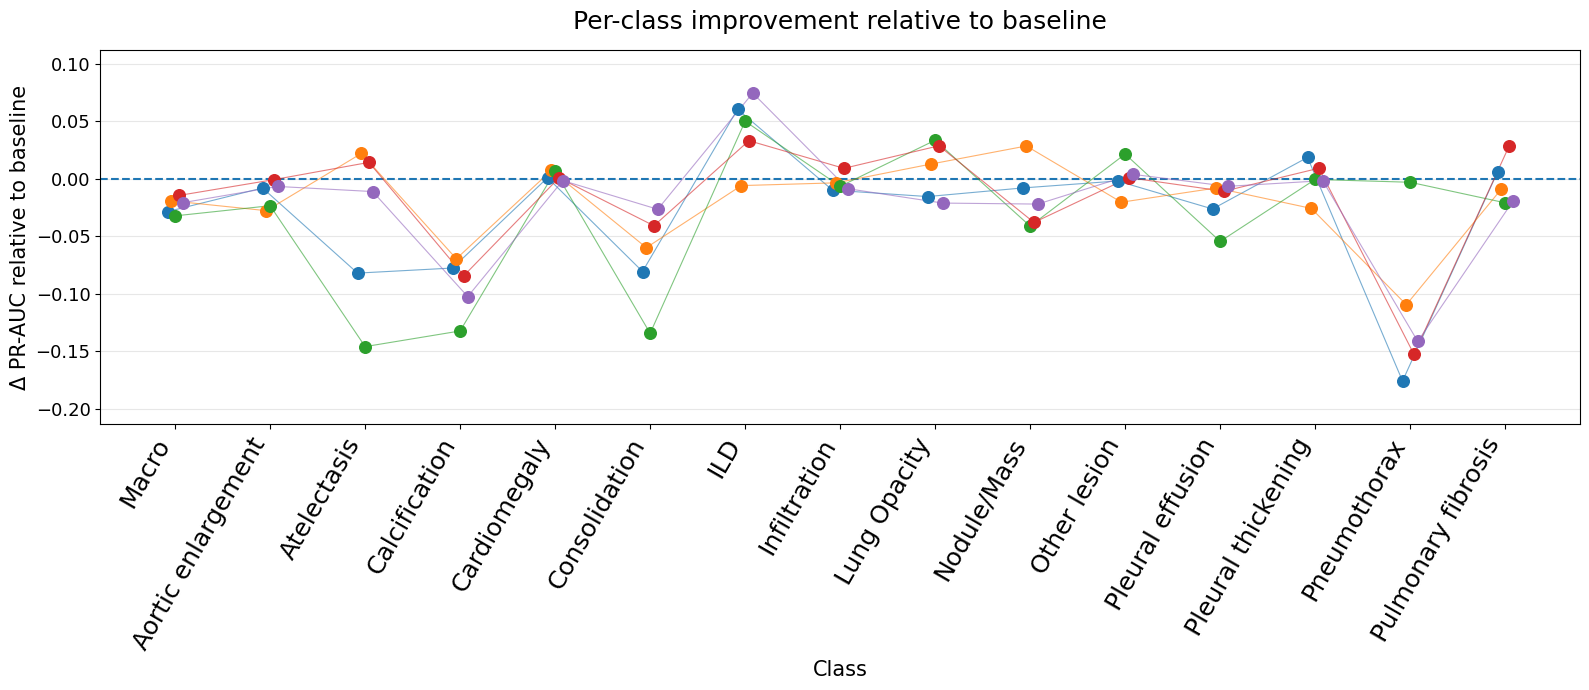

In [10]:
contrast_models = [
    "efficientnet_b4", 
    "efficientnet_b4_contrastclahe3", 
    "efficientnet_b4_contrastclahe2", 
    "efficientnet_b4_contrast_percentile", 
    "efficientnet_b4_contrastgamma08", 
    "efficientnet_b4_contrastgamma12"
    ]

comparison = compare_models(
    contrast_models,
    base_model,
    datadir,
    metric
)

plot_model_improvements(
    comparison,
    baseline_name=base_model
)

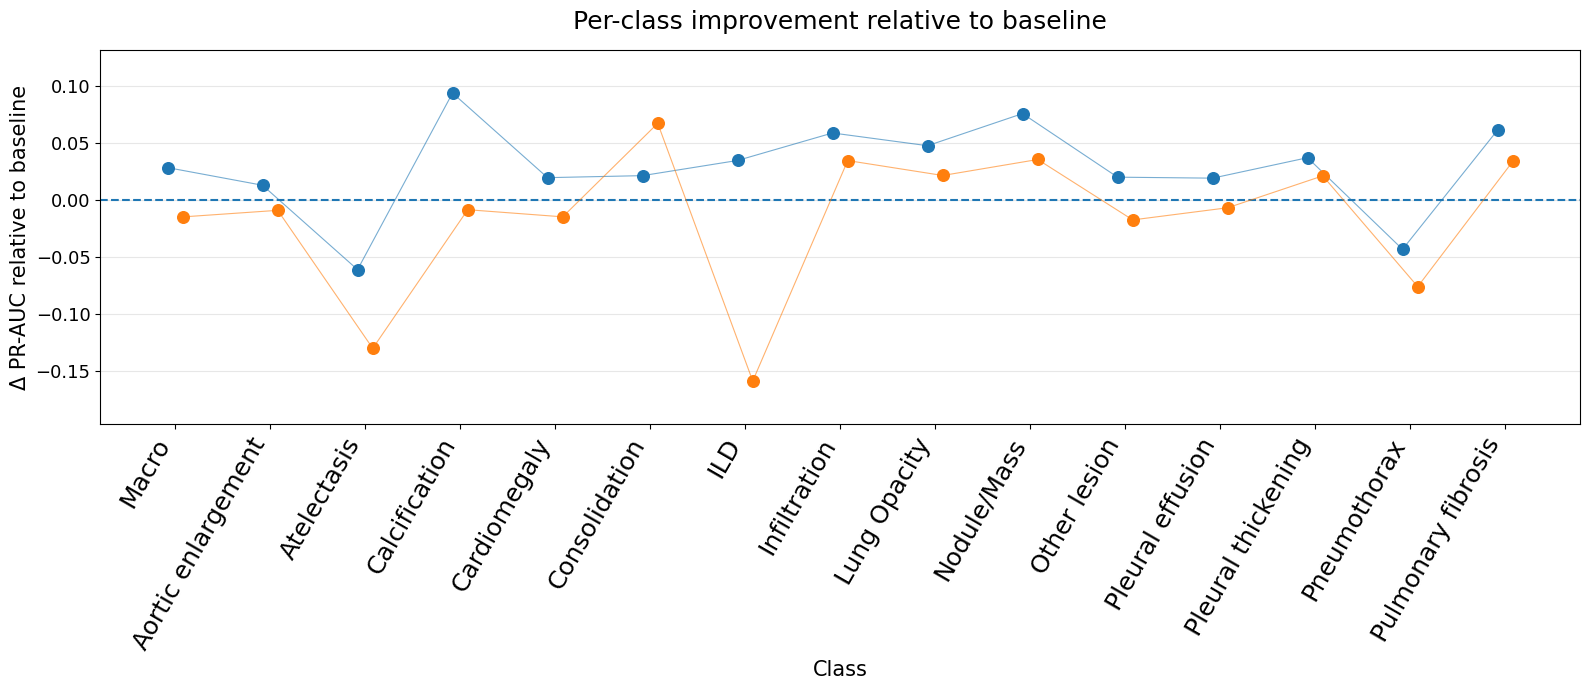

In [11]:
models = [
    "efficientnet_b4", 
    "efficientnet_b4_augmentation",
    "efficientnet_b4_contrastclahe3_augmentation"
    ]
comparison = compare_models(models, base_model, datadir, metric)
plot_model_improvements(
    comparison,
    baseline_name=base_model
)

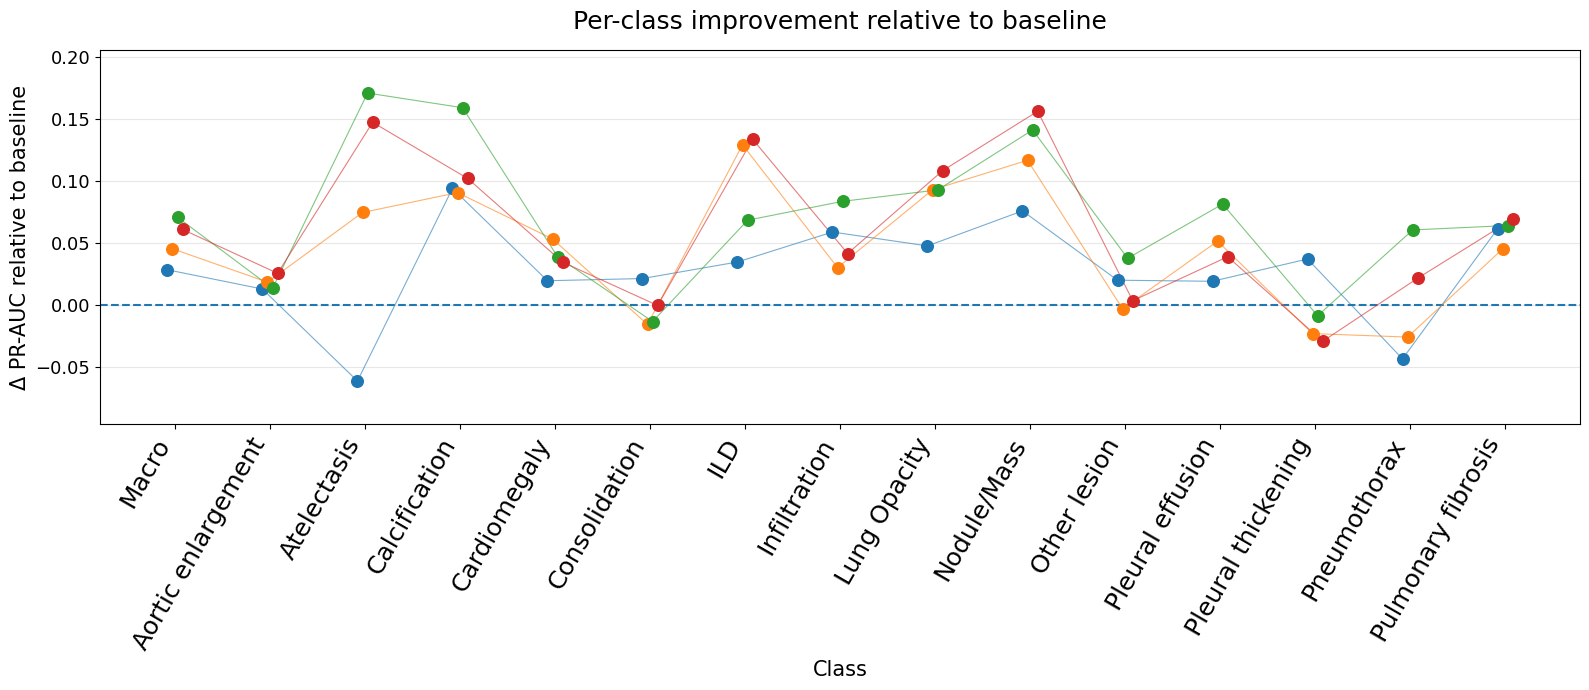

In [12]:
models = [
    "efficientnet_b4", 
    "efficientnet_b4_augmentation",
    "efficientnet_b4_augmentation-affine-contrastclahe-gaussnoise",
    "efficientnet_b4_augmentation-affine-contrastpercentile-gaussnoise",
    "efficientnet_b4_augmentation-affine-gamma08-gaussnoise"

    ]

comparison = compare_models(models, base_model, datadir, metric)
plot_model_improvements(
    comparison,
    baseline_name=base_model
)

In [13]:
def plot_best_epoch_per_class(
    models,
    datadir,
    metric="pr_auc",
    selection_metric="macro_pr_auc",
    figsize=(16, 7)
):
 
    datadir = Path(datadir)

    if metric not in ["pr_auc", "roc_auc"]:
        raise ValueError(
            "metric must be either 'pr_auc' or 'roc_auc'"
        )


    fig, ax = plt.subplots(figsize=figsize)

    for model in models:

        training_file = (
            datadir /
            f"training_metrics_model_{model}.csv"
        )

        training_df = pd.read_csv(training_file)
        best_idx = training_df[selection_metric].idxmax()
        best_epoch = training_df.loc[best_idx, "epoch"]
        per_class_file = (
            datadir /
            f"per_class_training_metrics_model_{model}.csv"
        )

        per_class_df = pd.read_csv(per_class_file)

        best_df = (
            per_class_df[
                per_class_df["epoch"] == best_epoch
            ]
            .sort_values("class")
        )
        x = np.arange(len(best_df))

        ax.plot(
            x,
            best_df[metric],
            linewidth=1,
            alpha=0.7,
            marker="o",
            markersize=6,
            label=f"{model} (epoch {best_epoch})"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        best_df["class"],
        rotation=60,
        ha="right",
        fontsize=13
    )

    ax.tick_params(
        axis="y",
        labelsize=13
    )

    ax.set_xlabel(
        "Class",
        fontsize=15
    )

    ax.set_ylabel(
        metric.upper(),
        fontsize=15
    )

    ax.set_title(
        f"Per-class {metric.upper()} at best epoch",
        fontsize=18,
        pad=15
    )

    ax.set_ylim(0, 1)

    ax.grid(
        axis="y",
        alpha=0.3
    )

    ax.legend(
        fontsize=11,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.30),
        ncol=2
    )
    plt.subplots_adjust(bottom=0.35)
    plt.show()

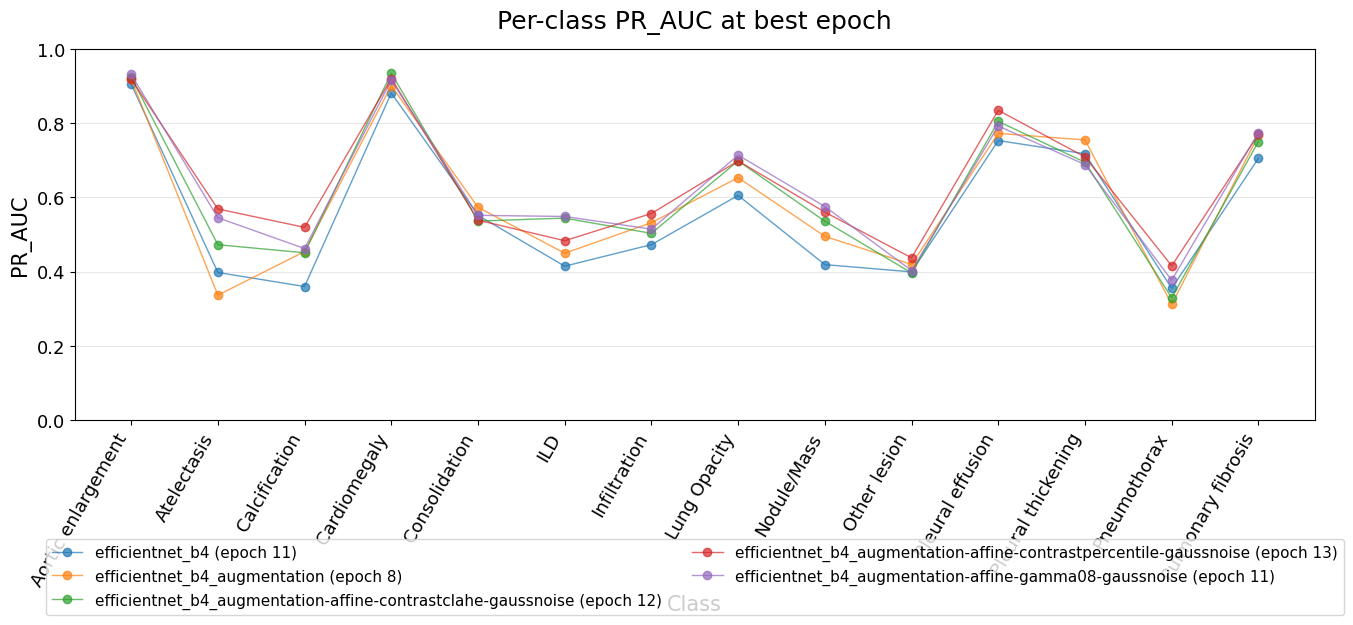

In [14]:
models = [
    "efficientnet_b4", 
    "efficientnet_b4_augmentation",
    "efficientnet_b4_augmentation-affine-contrastclahe-gaussnoise",
    "efficientnet_b4_augmentation-affine-contrastpercentile-gaussnoise",
    "efficientnet_b4_augmentation-affine-gamma08-gaussnoise"

]

plot_best_epoch_per_class(
    models,
    datadir,
    metric="pr_auc"
)

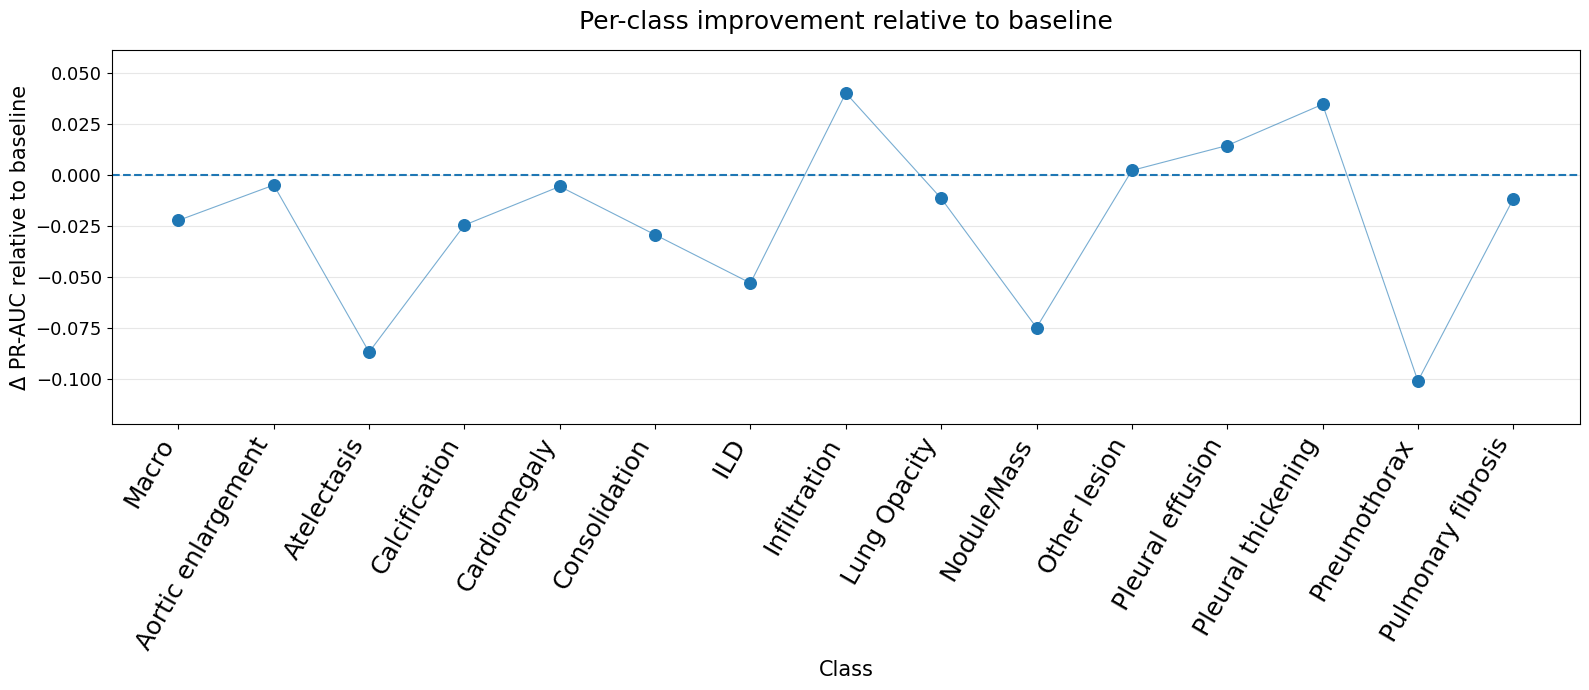

In [17]:
models = [
    "efficientnet_b4_augmentation-affine-gamma08-gaussnoise",
    "efficientnet_b4_augmentation-affine-gamma08-gaussnoise_bordercrop"]

base_model = "efficientnet_b4_augmentation-affine-gamma08-gaussnoise"

comparison = compare_models(models, base_model, datadir, metric)
plot_model_improvements(
    comparison,
    baseline_name=base_model
)

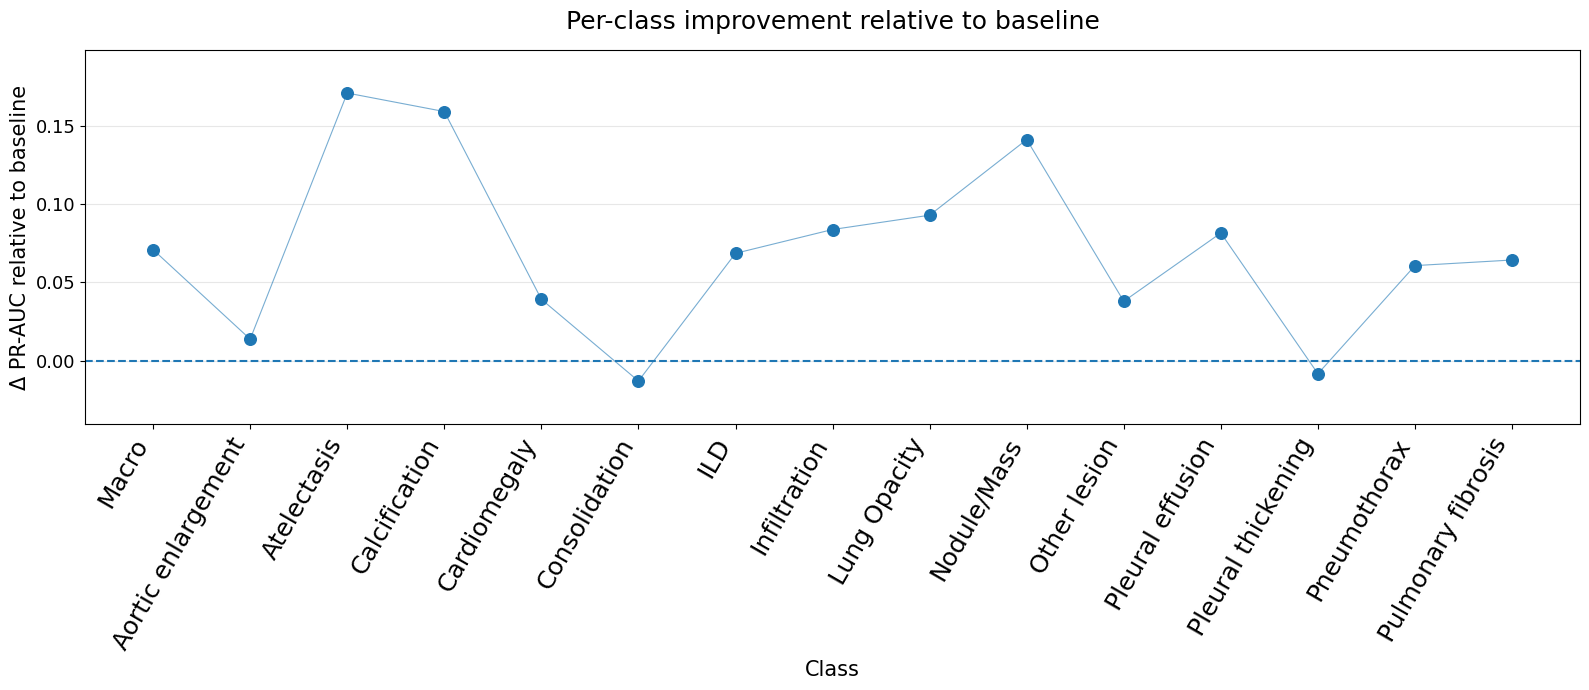

In [19]:
models = [
    "efficientnet_b4",
    "efficientnet_b4_augmentation-affine-contrastpercentile-gaussnoise"]

base_model = "efficientnet_b4"

comparison = compare_models(models, base_model, datadir, metric)
plot_model_improvements(
    comparison,
    baseline_name=base_model
)